# Lab Work: Developing and Comparing AI Models for Android Malware Detection

## Objective:
The goal of this lab is to develop and evaluate multiple AI models for detecting Android malware using the provided Android Malware Dataset. Students will choose at least three different machine learning or deep learning algorithms to compare their performance in classifying Android applications as benign or malicious.

## Dataset Overview:
The **Android Malware Dataset for Machine Learning** contains labeled Android APK samples, classified as benign (goodware) or malicious (e.g., adware, spyware, trojans). It includes various features extracted from the APKs, such as requested permissions, API calls, system behaviors, and more, which can be used to train machine learning models.

## Tasks:

1. **Data Preprocessing**:
   - Load the dataset and clean it by handling missing values and converting categorical features into numerical ones if necessary.
   - Split the data into training and testing sets.

2. **Model Development**:
   - Choose at least **three AI algorithms** of your choice (e.g., Logistic Regression, Random Forest, SVM, Neural Networks, XGBoost, etc.).
   - Train each model on the dataset and evaluate their performance using accuracy, precision, recall, F1-score, and confusion matrix.

3. **Model Comparison**:
   - Compare the models based on their performance metrics.
   - Analyze which model performs best and why.

4. **Optional (Hyperparameter Tuning)**:
   - Optionally, apply techniques like grid search to optimize the model’s hyperparameters.


## Resources:
- Kaggle Dataset: [Android Malware Dataset for Machine Learning](https://www.kaggle.com/datasets/shashwatwork/android-malware-dataset-for-machine-learning)

You need to login in Kaggle to get access to the dataset.


In [ ]:
#
#
#
#
# Your code to develop AI model for malware classification.
# Hint: Use the example code provided in previous lab.
#
#
#
#

In [35]:
import pandas as pd  # Importing pandas for data handling
import numpy as np  # Importing numpy for numerical operations
import seaborn as sns  # Importing seaborn for visualization
import matplotlib.pyplot as plt  # Importing matplotlib for plotting graphs
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Splitting dataset into train and test
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Encoding categorical variables and scaling data
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [3]:
df = pd.read_csv('C:/Users/olulo/Downloads/Compressed/archive/drebin-215-dataset-5560malware-9476-benign.csv', 
                 encoding="utf-8",
                 low_memory=False)

In [5]:
print("Total missing values before cleaning:", sum(list(df.isna().sum())))
#df.isna().sum()

Total missing values before cleaning: 0


In [7]:
df.shape

(15036, 216)

In [9]:
df.head()


,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S


In [13]:
# Map class labels to numeric values (B: Benign = 0, S: Malware = 1)
print("Converting class labels...")
df["class"] = df["class"].map({"B": 0, "S": 1})

Converting class labels...


In [17]:
# Handle missing values and special characters
print("Handling missing values and special characters...")
df = df.replace('[?,S]', np.NaN, regex=True)
print("Total missing values after replacing special chars:", sum(list(df.isna().sum())))
df.dropna(inplace=True)

Handling missing values and special characters...
Total missing values after replacing special chars: 5


In [21]:
# Convert all columns to numeric
print("Converting columns to numeric...")
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')


Converting columns to numeric...


In [23]:
# Drop any newly created NaN values
df.dropna(inplace=True)
print("Final data shape after cleaning:", df.shape)

Final data shape after cleaning: (15031, 216)


In [25]:
# Display class distribution
print("Analyzing class distribution...")
classes, count = np.unique(df['class'], return_counts=True)
print("Class counts:", dict(zip(classes, count)))

Analyzing class distribution...
Class counts: {0: 9476, 1: 5555}


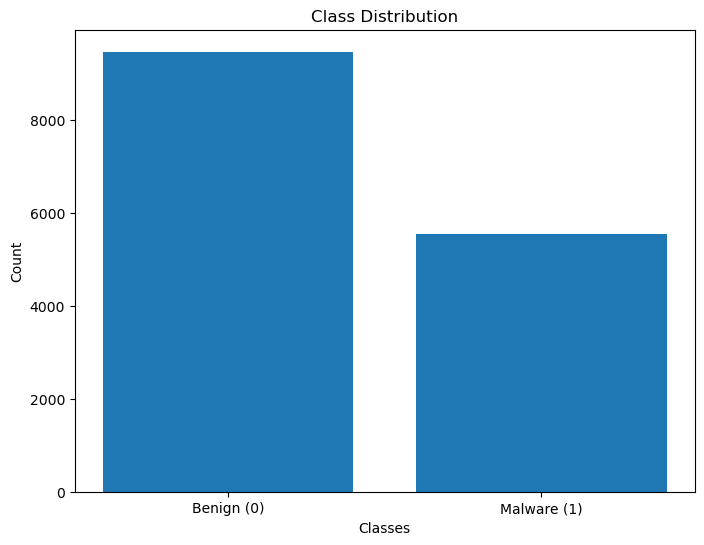

In [27]:
# Visualize class distribution
plt.figure(figsize=(8, 6))
plt.bar(['Benign (0)', 'Malware (1)'], count)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

In [29]:
# Check for class imbalance and apply oversampling if necessary
X = df.drop("class", axis=1)
y = df["class"]

In [31]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [39]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

# XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))


Logistic Regression Accuracy: 0.9770535417359495
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1886
           1       0.97      0.97      0.97      1121

    accuracy                           0.98      3007
   macro avg       0.98      0.98      0.98      3007
weighted avg       0.98      0.98      0.98      3007

Random Forest Accuracy: 0.9876953774526106
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1886
           1       0.99      0.97      0.98      1121

    accuracy                           0.99      3007
   macro avg       0.99      0.98      0.99      3007
weighted avg       0.99      0.99      0.99      3007

XGBoost Accuracy: 0.9876953774526106
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1886
           1       0.99      0.98      0.98      1121

    accuracy                           0.99      3007

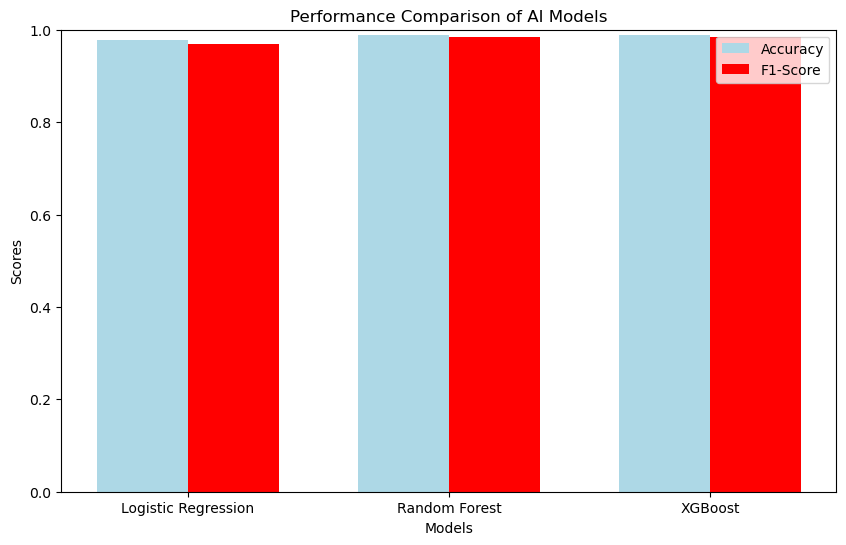

In [50]:
# Collect results manually after running each model

# Add your printed accuracy and f1-score values here:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

# Plot
import matplotlib.pyplot as plt

model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracy_scores = [accuracy_lr, accuracy_rf, accuracy_xgb]
f1_scores = [f1_lr, f1_rf, f1_xgb]

x = range(len(model_names))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Accuracy bars
plt.bar(x, accuracy_scores, width=bar_width, label='Accuracy', color='lightblue')

# F1-Score bars (next to it)
plt.bar([p + bar_width for p in x], f1_scores, width=bar_width, label='F1-Score', color='red')

# Labels
ax.set_xlabel('Models')
ax.set_ylabel('Scores')
ax.set_title('Performance Comparison of AI Models')
ax.set_xticks([p + bar_width/2 for p in x])
ax.set_xticklabels(model_names)
plt.legend()
plt.ylim([0, 1])
plt.show()

**Lab Logbook requirement**: Provide a graph comparing the performance of the AI model that you have developed.